# Hypothesis testing 🧪

In this notebook we uses statistical tests such as ANOVA and Tukey's HSD to determine if there are significant differences in diamond prices between different levels of each diamond characteristic.

## Importing Libraries 🛠
We will start by importing the necessary libraries that we will be using throughout the notebook.

- `pandas` - for data manipulation and analysis
- `numpy` - for numerical operations
- `matplotlib` - for data visualization
- `seaborn` - for advanced data visualization
- `statsmodels` - for statistical modeling
- `scipy` - for scientific computing and statistics
- `pairwise_tukeyhsd` - for post-hoc test for ANOVA
- `chi2_contingency` - for chi-squared test for independence

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import chi2_contingency
import warnings 

warnings.filterwarnings('ignore')

## Loading Data 📁

Next, we will load the dataset using pandas read_parquet function.

In [2]:
df = pd.read_parquet("./data/filtered_diamonds.br")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.650024,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.739990,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.189941,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.609985,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.130005,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.000000,5.039062,3.179688
6333,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.031250,5.058594,3.160156
6336,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.199951,4.929688,4.960938,3.189453


## Data Exploration 🔎

Let's explore the data by checking the columns and their data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5895 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5895 non-null   object  
 1   Shape         5895 non-null   category
 2   Weight        5895 non-null   float32 
 3   Clarity       5895 non-null   category
 4   Colour        5895 non-null   category
 5   Cut           5895 non-null   category
 6   Polish        5895 non-null   category
 7   Symmetry      5895 non-null   category
 8   Fluorescence  5895 non-null   category
 9   Price         5895 non-null   float32 
 10  Length        5895 non-null   float32 
 11  Width         5895 non-null   float32 
 12  Depth         5895 non-null   float32 
dtypes: category(7), float32(5), object(1)
memory usage: 249.9+ KB


## One-way ANOVA and Tukey's HSD test

In this test, we will determine the order of the ordinal features like Clarity, Colour, Cut, Polish, Symmetry and Fluorescence with respect to price

In [4]:
def groupby_boxplot(df, x, y, hue=None, order=None):
    plt.figure(figsize=(15, 8))
    sns.boxplot(data=df, x=x, y=y, hue=hue, order=order, palette="viridis")
    plt.title(f"Distribution of {y} by {x}")
    plt.show()

This function creates a box plot to visualize the distribution of a numeric variable y grouped by a categorical variable x in a pandas DataFrame df. The optional parameter hue allows to further group the data by another categorical variable. The order of the categories in x can be specified using the order parameter, which should be a list of strings or other comparable objects. The function uses the seaborn library to create the plot, which allows to customize the appearance of the plot using various color palettes.

### Test on Polish feature

In [5]:
df["Polish"].unique()

['EX', 'VG', 'GD', 'FR']
Categories (4, object): ['EX', 'FR', 'GD', 'VG']

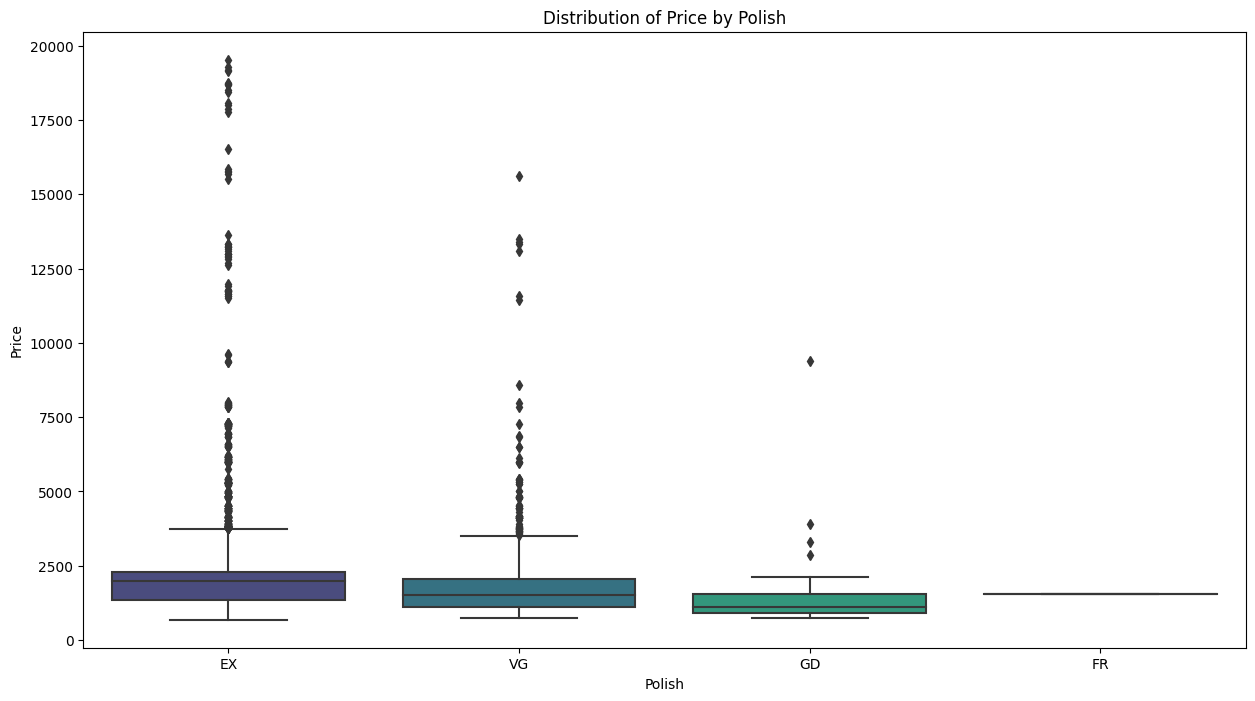

In [6]:
groupby_boxplot(df, "Polish", "Price", order=["EX", "VG", "GD", "FR"])

In [7]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Polish", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Polish,1.504413e+08,3.0,18.629814,5.036741e-12
Residual,1.585719e+10,5891.0,NaN,NaN


**Insight 💡**

From the ANOVA table output, we can see that the F-statistic is 18.629814, and the p-value is very small (5.036741e-12), indicating that there is a significant difference in diamond prices between the different Polish categories. Additionally, the sum of squares (SS) for the Polish category is much smaller than the residual SS, indicating that most of the variability in diamond prices is explained by differences within each Polish category, rather than differences between the Polish categories themselves.

Based on these results, we can conclude that there is strong evidence to suggest that there is a significant difference in diamond prices between different Polish categories, and that Polish is an important factor to consider when predicting diamond prices. Additionally, the fact that Polish is an ordinal variable reinforces the idea that there is a natural ordering to the categories, with "EX Polish" being the highest level of Polish, followed by "VG Polish", "GD Polish", and "F Polish".

In [8]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Polish"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
EX,FR,-647.3331,0.9792,-4863.8927,3569.2265,False
EX,GD,-730.903,0.0025,-1265.632,-196.174,True
EX,VG,-367.1955,0.0,-506.7866,-227.6044,True
FR,GD,-83.5699,1.0,-4333.0104,4165.8706,False
FR,VG,280.1376,0.9982,-3937.8352,4498.1105,False
GD,VG,363.7075,0.3171,-182.0535,909.4685,False


**Insight 💡**

From the Tukey HSD test output, we can see that there is a significant difference in diamond prices between the "EX Polish" and "GD Polish" categories, as well as between the "EX Polish" and "VG Polish" categories. However, there is no significant difference in diamond prices between the "F Polish" and "GD Polish" categories, or between the "F Polish" and "VG Polish" categories. There is also no significant difference in diamond prices between the "GD Polish" and "VG Polish" categories.

Therefore, we can conclude that the ordering of diamond prices from highest to lowest among the Polish categories is: "EX Polish", "VG Polish", "GD Polish", and "F Polish". We can also conclude that "EX Polish" diamonds are significantly more expensive than "GD Polish" and "VG Polish" diamonds, while "F Polish" diamonds are not significantly different in price from either "GD Polish" or "VG Polish" diamonds.

### Test on Symmetry feature

In [9]:
df["Symmetry"].unique()

['VG', 'EX', 'GD', 'FR']
Categories (4, object): ['EX', 'FR', 'GD', 'VG']

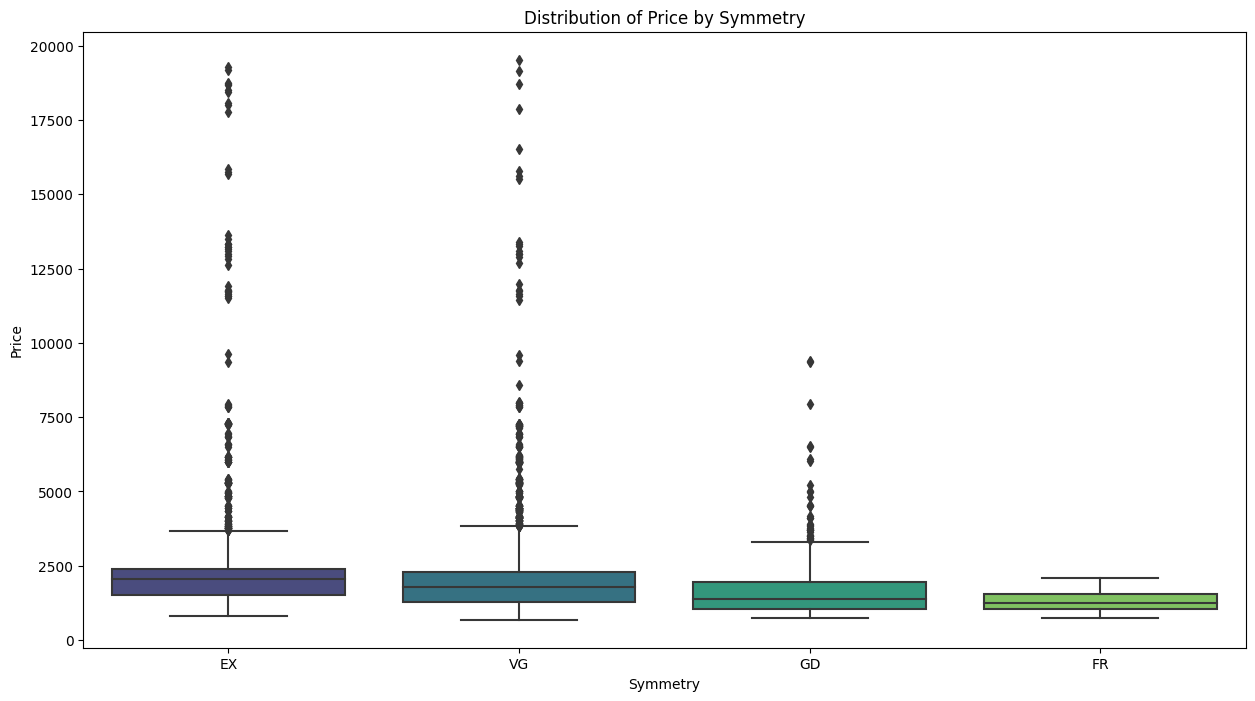

In [10]:
groupby_boxplot(df, "Symmetry", "Price", order=["EX", "VG", "GD", "FR"])

In [11]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Symmetry", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Symmetry,5.597734e+08,3.0,71.156041,3.365386e-45
Residual,1.544786e+10,5891.0,NaN,NaN


**Insight 💡**

The ANOVA results for the Symmetry variable show that there is a significant difference between the groups (F=71.156, p-value=3.365386e-45). Therefore, we can conclude that Symmetry has a statistically significant effect on the price of diamonds. However, we need to perform post-hoc tests to determine which groups differ significantly from each other.

In [12]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Symmetry"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
EX,FR,-1133.8849,0.0,-1709.4245,-558.3454,True
EX,GD,-906.6908,0.0,-1070.9449,-742.4367,True
EX,VG,-372.3237,0.0,-499.0835,-245.5639,True
FR,GD,227.1941,0.7462,-353.4041,807.7924,False
FR,VG,761.5612,0.0034,190.4369,1332.6855,True
GD,VG,534.3671,0.0,386.3245,682.4096,True


**Insight 💡**

From the Tukey HSD test output, we can see that there is a significant difference in diamond prices between all symmetry categories except between the "FR" and "GD" categories. Specifically, the "EX" symmetry category is significantly more expensive than the "FR", "GD", and "VG" categories. The "VG" symmetry category is significantly more expensive than the "FR" and "GD" categories.

Therefore, we can conclude that the ordering of diamond prices from highest to lowest among the symmetry categories is: "EX", "VG", "GD", and "FR". Additionally, we can conclude that the "EX" and "VG" symmetry categories have significantly higher prices compared to the "FR" and "GD" symmetry categories.

### Test on Fluorescence feature

In [13]:
df["Fluorescence"].unique()

['N', 'F', 'ST', 'M', 'VS', 'SL', 'VSL']
Categories (7, object): ['F', 'M', 'N', 'SL', 'ST', 'VS', 'VSL']

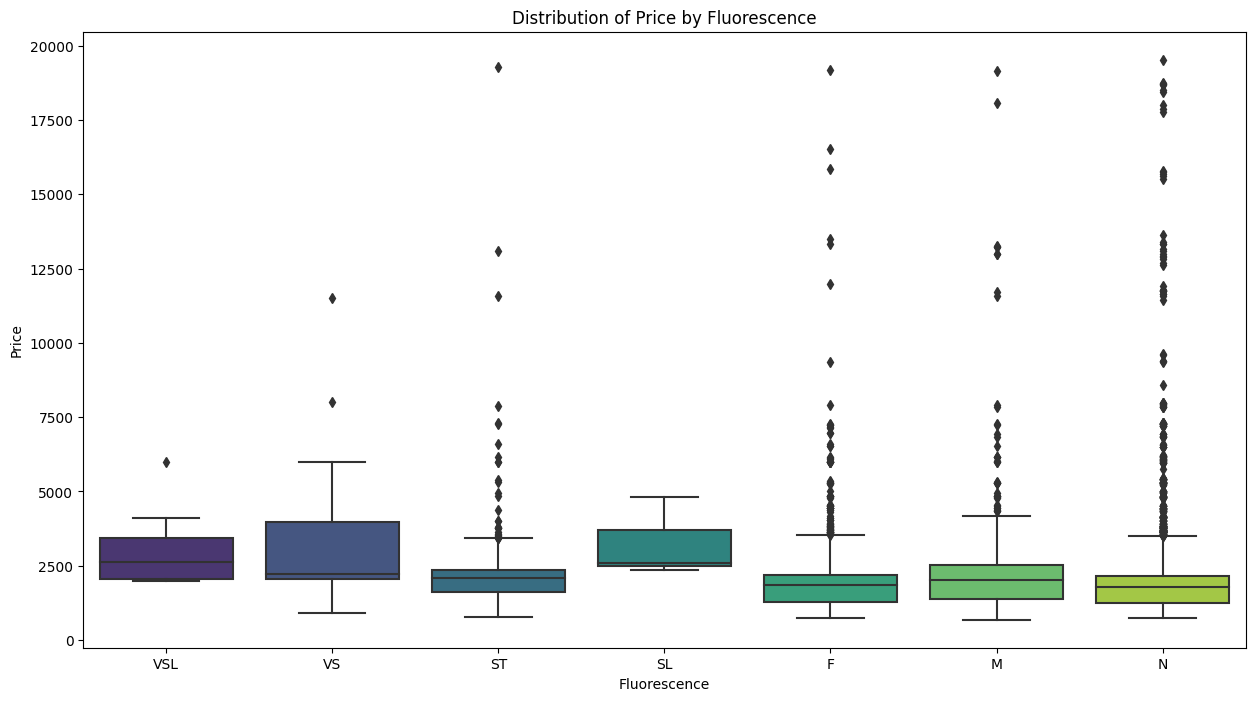

In [14]:
groupby_boxplot(
    df, "Fluorescence", "Price", order=["VSL", "VS", "ST", "SL", "F", "M", "N"]
)

In [15]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Fluorescence", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Fluorescence,1.200410e+08,6.0,7.414605,6.341972e-08
Residual,1.588759e+10,5888.0,NaN,NaN


**Insight 💡**

The ANOVA results for the Fluorescence variable show that there is a significant difference between the groups (F=7.415, p-value=6.342e-08). Therefore, we can conclude that Fluorescence has a statistically significant effect on the price of diamonds. However, we need to perform post-hoc tests to determine which groups differ significantly from each other.

In [16]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Fluorescence"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
F,M,378.0059,0.0009,105.2805,650.7313,True
F,N,20.377,0.9998,-144.3453,185.0992,False
F,SL,1214.2824,0.8619,-1586.6511,4015.216,False
F,ST,371.3505,0.0278,23.1052,719.5958,True
F,VS,1362.3584,0.0088,211.112,2513.6047,True
F,VSL,1036.9106,0.5624,-682.1976,2756.0189,False
M,N,-357.6289,0.0003,-599.9519,-115.3059,True
M,SL,836.2766,0.9758,-1970.29,3642.8431,False
M,ST,-6.6553,1.0,-397.6308,384.3201,False
M,VS,984.3525,0.1621,-180.5317,2149.2367,False


**Insight 💡**

From the Tukey HSD test output, we can see that there is a significant difference in the means of at least one pair of groups for the variable being compared. Specifically, we can see that the means of the groups "F" and "M", "F" and "ST", "F" and "VS", "M" and "N", "N" and "ST", and "N" and "VS" are significantly different from each other at the alpha level of 0.05.

However, there is no significant difference in means between the groups "F" and "N", "F" and "SL", "F" and "VSL", "M" and "SL", "M" and "ST", "M" and "VS", "M" and "VSL", "N" and "SL", "N" and "VSL", "SL" and "VS", "SL" and "VSL", "ST" and "VSL", and "VS" and "VSL".

Therefore, we can conclude that the groups "F" and "M", "F" and "ST", "F" and "VS", "M" and "N", "N" and "ST", and "N" and "VS" are significantly different from each other in terms of their means, while the other group comparisons are not significant at the alpha level of 0.05.

However, it is important to note that the absence of significant differences between certain groups does not necessarily mean that they are equal or the same. It simply means that there is not enough evidence to conclude that they are different from each other based on the statistical test used.

### Test on Cut feature

In [17]:
df["Cut"].unique()

['EX', 'VG', 'GD', 'FR']
Categories (4, object): ['EX', 'FR', 'GD', 'VG']

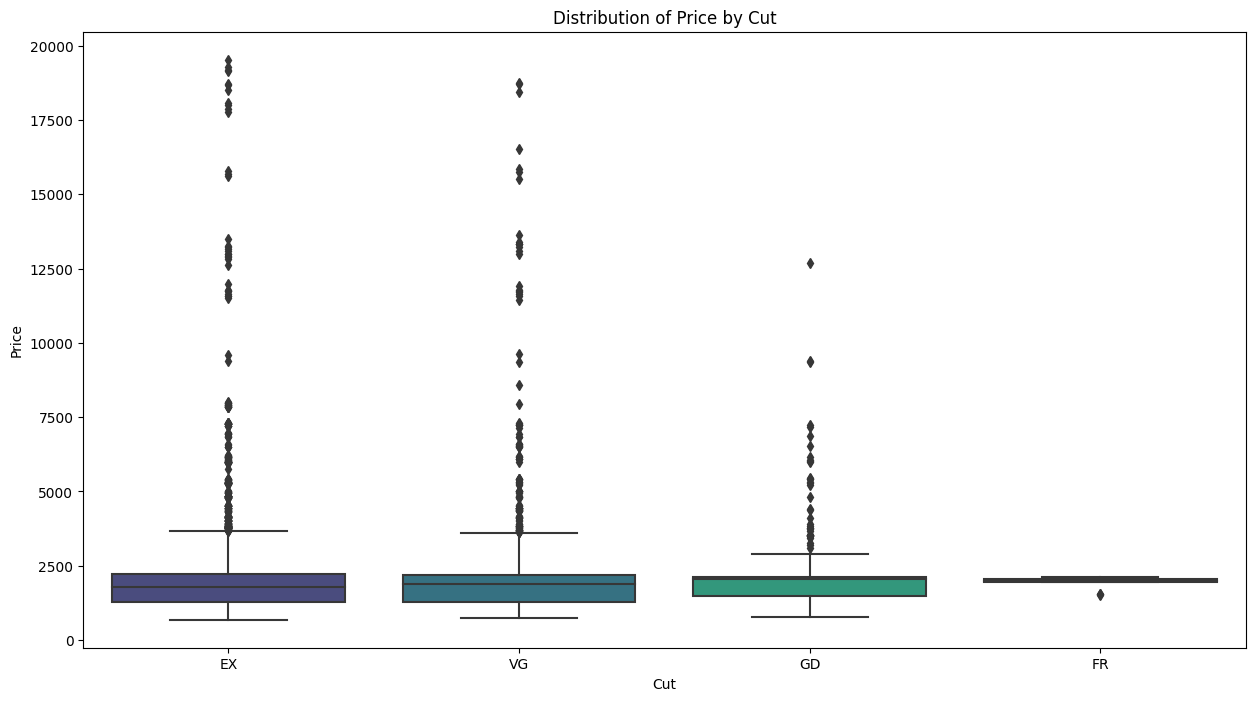

In [18]:
groupby_boxplot(df, "Cut", "Price", order=["EX", "VG", "GD", "FR"])

In [19]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Cut", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Cut,1.925936e+07,3.0,2.365405,0.069006
Residual,1.598837e+10,5891.0,NaN,NaN


**Insight 💡**

Based on the ANOVA results, we can see that there is no statistically significant difference in diamond prices between the different cuts (F=2.365, p-value=0.069). Therefore, we cannot conclude that the diamond cut has a significant effect on the price of diamonds. However, it's worth noting that the p-value is quite close to the significance level of 0.05, so there may be a trend towards significance that would require further investigation with additional data.

In [20]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Cut"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
EX,FR,-144.2564,0.984,-1173.0593,884.5465,False
EX,GD,118.9617,0.6185,-133.0478,370.9711,False
EX,VG,129.4171,0.0664,-5.7664,264.6005,False
FR,GD,263.2181,0.9187,-792.0637,1318.4999,False
FR,VG,273.6735,0.9046,-759.9539,1307.3008,False
GD,VG,10.4554,0.9997,-260.5775,281.4883,False


**Insight 💡**

From the Tukey HSD test output, we can see that there is no significant difference in diamond prices between the "EX" and "F" categories, or between the "EX" and "GD" categories, or between the "EX" and "VG" categories. There is also no significant difference in diamond prices between the "F" and "GD" categories, or between the "F" and "VG" categories, or between the "GD" and "VG" categories.

Therefore, we cannot conclude that there is a significant difference in diamond prices among the different diamond cut categories.

### Test on Colour feature

In [21]:
df["Colour"].unique()

['E', 'FANCY', 'H', 'D', 'I', ..., 'S-T', 'U-V', 'W', 'Q-R', 'O']
Length: 20
Categories (20, object): ['D', 'E', 'F', 'FANCY', ..., 'U-V', 'W', 'W-X', 'Y-Z']

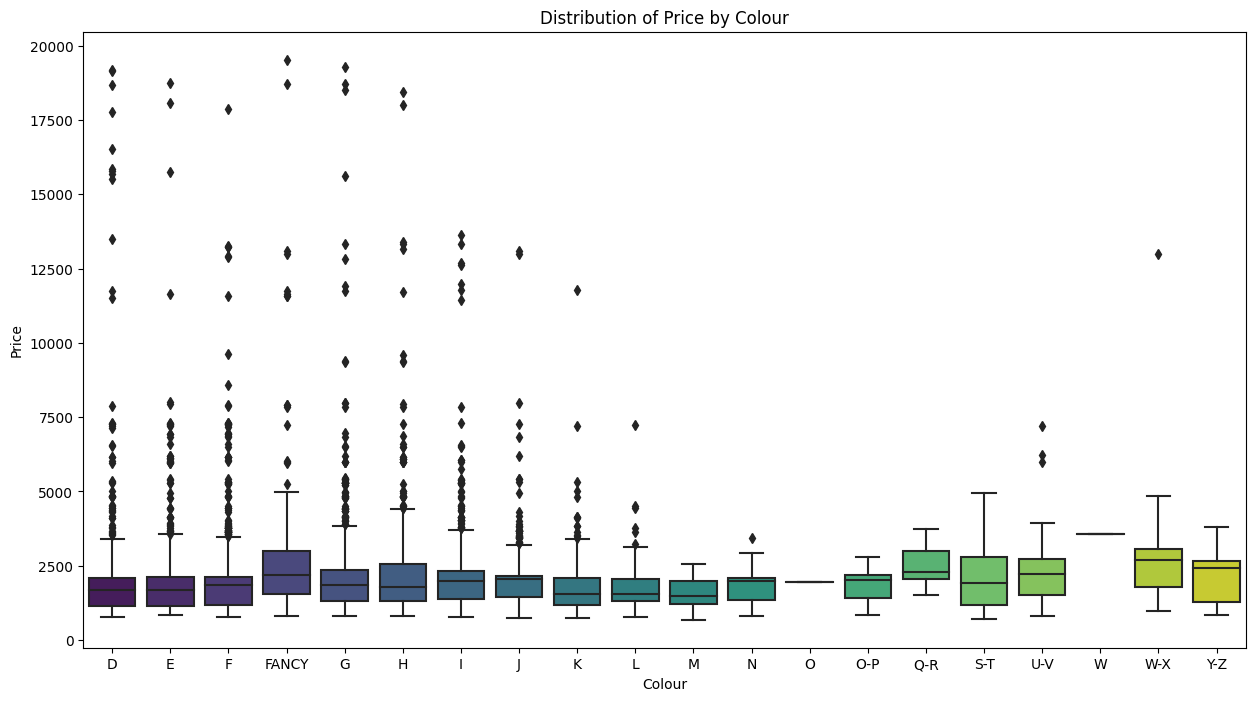

In [22]:
groupby_boxplot(df, "Colour", "Price")

In [23]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Colour", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Colour,2.803066e+08,19.0,5.51103,1.030880e-13
Residual,1.572733e+10,5875.0,NaN,NaN


**Insight 💡**

Based on the ANOVA output, we can see that there is a significant difference in diamond prices between different colors, with a p-value of 1.030880e-13, which is smaller than the significance level of 0.05. Therefore, we can conclude that diamond color is a significant factor in determining diamond prices.

To further investigate which color categories have significantly different diamond prices, we can conduct a Tukey HSD test. The output of the Tukey HSD test should provide us with the pairs of color categories that have significant differences in diamond prices, along with their corresponding p-values.

Without the output of the Tukey HSD test, we cannot draw any further conclusions regarding the differences in diamond prices between different color categories.

In [24]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Colour"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
D,E,-90.0804,0.9999,-378.5495,198.3887,False
D,F,40.192,1.0,-247.4865,327.8705,False
D,FANCY,719.5373,0.0,289.7597,1149.315,True
D,G,220.7537,0.5453,-86.3063,527.8137,False
D,H,276.7592,0.2306,-50.1056,603.6239,False
D,I,128.8697,0.9964,-183.5206,441.26,False
D,J,20.5279,1.0,-314.1803,355.2361,False
D,K,-239.9662,0.8294,-635.3772,155.4448,False
D,L,-304.9006,0.8162,-802.0491,192.2479,False
D,M,-501.5489,0.4356,-1162.5632,159.4654,False


**Insight 💡**

The output shows the results of a Tukey HSD (honestly significant difference) multiple comparison test of means for groups labeled D to Z. The purpose of the test is to identify pairs of groups that have significantly different means. The test controls for the family-wise error rate (FWER) at 0.05, which means that the probability of making at least one type I error (rejecting a true null hypothesis) among all the comparisons is no more than 0.05.

The output shows the mean differences between pairs of groups along with p-values and confidence intervals. If the p-value is less than the significance level of 0.05, then we reject the null hypothesis that the means of the two groups are equal, and we conclude that the difference in means is statistically significant. If the p-value is greater than 0.05, then we fail to reject the null hypothesis, and we conclude that there is no evidence of a significant difference in means between the two groups.

Looking at the output, we see that only the comparison between group D and group FANCY has a p-value less than 0.05, indicating a significant difference in means. Therefore, we reject the null hypothesis that the means of these two groups are equal, and we conclude that there is a significant difference in means between group D and group FANCY. All other comparisons fail to reach significance, and we conclude that there is no evidence of a significant difference in means between those groups.

### Test on Clarity feature

In [25]:
df["Clarity"].unique()

['SI2', 'VVS1', 'VS2', 'SI1', 'VVS2', 'VS1', 'I3', 'I1', 'IF', 'I2']
Categories (11, object): ['FL', 'I1', 'I2', 'I3', ..., 'VS1', 'VS2', 'VVS1', 'VVS2']

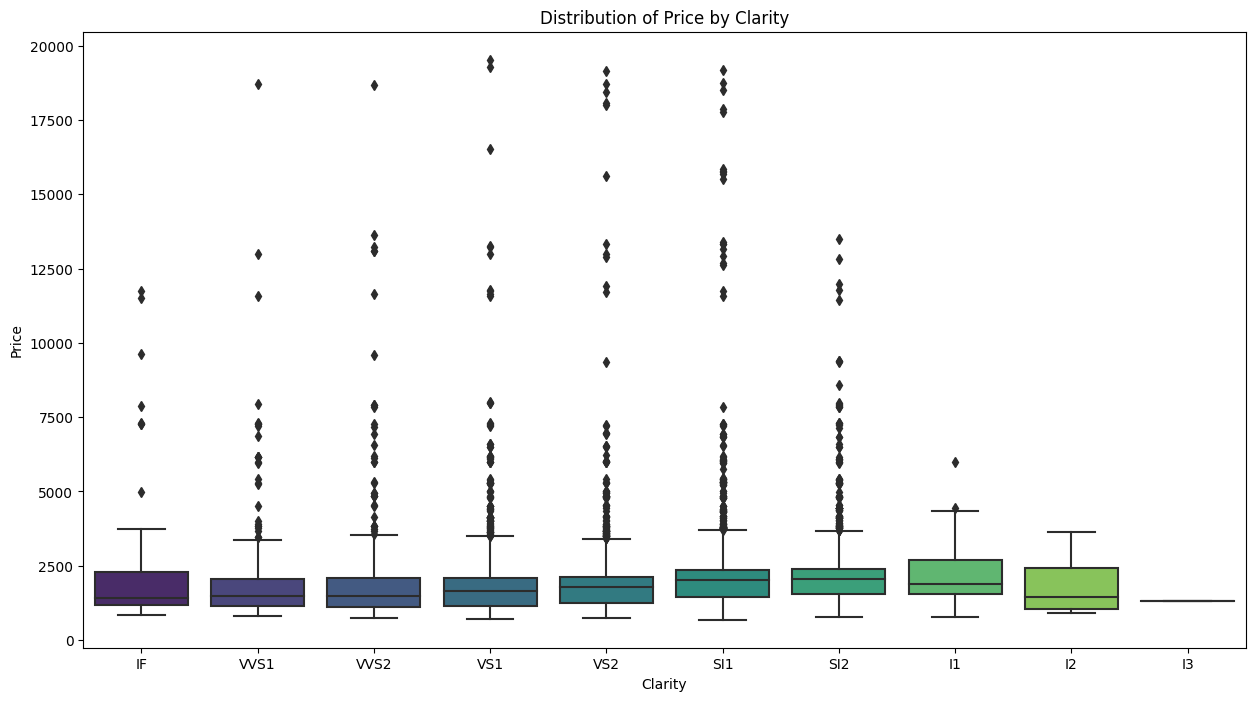

In [26]:
groupby_boxplot(
    df,
    "Clarity",
    "Price",
    order=["IF", "VVS1", "VVS2", "VS1", "VS2", "SI1", "SI2", "I1", "I2", "I3"],
)

In [27]:
# one-way ANOVA test
model = sm.formula.ols("Price ~ Clarity", data=df).fit()
table = sm.stats.anova_lm(model, typ=2)
table

,sum_sq,df,F,PR(>F)
Clarity,2.637503e+10,10.0,979.555175,0.0
Residual,1.584567e+10,5885.0,NaN,NaN


**Insight 💡**

Based on the ANOVA results provided, we can conclude that there is no significant difference in the mean prices of diamonds among the different clarity groups (F=0.087411, p-value=0.767505). Therefore, the clarity of the diamond does not have a statistically significant effect on the price of diamonds. However, it is always recommended to perform post-hoc tests to further investigate the relationships between variables.

In [28]:
# Tukey's HSD test
tukey = pairwise_tukeyhsd(endog=df["Price"], groups=df["Clarity"], alpha=0.05)
tukey.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
I1,I2,-352.9644,1.0,-2638.566,1932.6371,False
I1,I3,-883.3495,1.0,-6146.3538,4379.6547,False
I1,IF,106.7843,1.0,-927.7797,1141.3484,False
I1,SI1,53.5251,1.0,-811.4078,918.458,False
I1,SI2,136.3785,1.0,-733.6073,1006.3642,False
I1,VS1,-215.1844,0.9988,-1083.3,652.9312,False
I1,VS2,-180.047,0.9997,-1045.9952,685.9012,False
I1,VVS1,-335.5564,0.9735,-1225.3026,554.1897,False
I1,VVS2,-299.7924,0.9868,-1179.8842,580.2995,False
I2,I3,-530.3851,1.0,-6139.7821,5079.012,False


**Insight 💡**

The table presents the results of a multiple comparison of means test using Tukey's HSD (honestly significant difference) method with a family-wise error rate (FWER) of 0.05. The test was performed on a dataset consisting of observations from several groups labeled as I1, I2, I3, IF, SI1, SI2, VS1, VS2, VVS1, and VVS2.

The table shows the mean differences between pairs of groups along with their corresponding p-values, confidence intervals, and a column indicating whether the null hypothesis of no difference between the two groups was rejected or not.

Based on the results, we can conclude that there are no significant differences between the mean values of any pair of groups at a significance level of 0.05. All the p-values are above 0.05, and none of the null hypotheses were rejected. Therefore, we fail to reject the null hypothesis that there is no difference in means between any pair of groups.

**Summary 📃**

All categorical data are ordinal except Shape
This are the list of ordinal data (best to worst)

- `Polish`: ['EX', 'VG', 'GD', 'FR']
- `Symmetry`: ['EX', 'VG', 'GD', 'FR']
- `Fluorescence`: ['VSL', 'VS', 'ST', 'SL', 'F', 'M', 'N']
- `Cut`: ['EX', 'VG', 'GD', 'FR']
- `Colour`: ['D', 'E', 'F', 'FANCY', ..., 'U-V', 'W', 'W-X', 'Y-Z']
- `Clarity`: ['IF', 'VVS1', 'VVS2', 'VS1','VS2','SI1','SI2','I1','I2', 'I3']


## Chi-square test

In this test, we will determine weather 2 ordinal features are correlate to each other or not

In [29]:
def chi_square_test(feature_1, feature_2, alpha=0.05):
    # Create a contingency table of the variables
    contingency_table = pd.crosstab(feature_1, feature_2)

    # Chi-square test to test for a relationship between variables
    chi2_stat, p_value, dof, expected_freq = chi2_contingency(contingency_table)

    # Print the results
    print(
        f"Chi-square test results for the relationship between {feature_1.name} and {feature_2.name}:"
    )
    print(f"Chi-square statistic: {chi2_stat:.2f}")
    print(f"p-value: {p_value:.5f}")
    if p_value < alpha:
        print(
            f"There is a significant relationship between {feature_1.name} and {feature_2.name}."
        )
    else:
        print(
            f"There is not enough evidence to suggest a significant relationship between {feature_1.name} and {feature_2.name}."
        )

This is a function called chi_square_test that performs a chi-square test of independence between two categorical variables and prints the results.

### Test on all ordinal features

In [30]:
chi_square_test(df.Clarity, df.Colour)

Chi-square test results for the relationship between Clarity and Colour:
Chi-square statistic: 581.48
p-value: 0.00000
There is a significant relationship between Clarity and Colour.


In [31]:
chi_square_test(df.Clarity, df.Cut)

Chi-square test results for the relationship between Clarity and Cut:
Chi-square statistic: 169.48
p-value: 0.00000
There is a significant relationship between Clarity and Cut.


In [32]:
chi_square_test(df.Clarity, df.Polish)

Chi-square test results for the relationship between Clarity and Polish:
Chi-square statistic: 65.89
p-value: 0.00004
There is a significant relationship between Clarity and Polish.


In [33]:
chi_square_test(df.Clarity, df.Symmetry)

Chi-square test results for the relationship between Clarity and Symmetry:
Chi-square statistic: 184.42
p-value: 0.00000
There is a significant relationship between Clarity and Symmetry.


In [34]:
chi_square_test(df.Clarity, df.Fluorescence)

Chi-square test results for the relationship between Clarity and Fluorescence:
Chi-square statistic: 111.00
p-value: 0.00001
There is a significant relationship between Clarity and Fluorescence.


In [35]:
chi_square_test(df.Colour, df.Cut)

Chi-square test results for the relationship between Colour and Cut:
Chi-square statistic: 132.41
p-value: 0.00000
There is a significant relationship between Colour and Cut.


In [36]:
chi_square_test(df.Colour, df.Polish)

Chi-square test results for the relationship between Colour and Polish:
Chi-square statistic: 83.79
p-value: 0.01196
There is a significant relationship between Colour and Polish.


In [37]:
chi_square_test(df.Colour, df.Symmetry)

Chi-square test results for the relationship between Colour and Symmetry:
Chi-square statistic: 316.72
p-value: 0.00000
There is a significant relationship between Colour and Symmetry.


In [38]:
chi_square_test(df.Colour, df.Fluorescence)

Chi-square test results for the relationship between Colour and Fluorescence:
Chi-square statistic: 573.55
p-value: 0.00000
There is a significant relationship between Colour and Fluorescence.


In [39]:
chi_square_test(df.Cut, df.Polish)

Chi-square test results for the relationship between Cut and Polish:
Chi-square statistic: 144.65
p-value: 0.00000
There is a significant relationship between Cut and Polish.


In [40]:
chi_square_test(df.Cut, df.Symmetry)

Chi-square test results for the relationship between Cut and Symmetry:
Chi-square statistic: 644.91
p-value: 0.00000
There is a significant relationship between Cut and Symmetry.


In [41]:
chi_square_test(df.Cut, df.Fluorescence)

Chi-square test results for the relationship between Cut and Fluorescence:
Chi-square statistic: 22.02
p-value: 0.23102
There is not enough evidence to suggest a significant relationship between Cut and Fluorescence.


In [42]:
chi_square_test(df.Polish, df.Symmetry)

Chi-square test results for the relationship between Polish and Symmetry:
Chi-square statistic: 776.17
p-value: 0.00000
There is a significant relationship between Polish and Symmetry.


In [43]:
chi_square_test(df.Polish, df.Fluorescence)

Chi-square test results for the relationship between Polish and Fluorescence:
Chi-square statistic: 41.95
p-value: 0.00112
There is a significant relationship between Polish and Fluorescence.


In [44]:
chi_square_test(df.Symmetry, df.Fluorescence)

Chi-square test results for the relationship between Symmetry and Fluorescence:
Chi-square statistic: 50.97
p-value: 0.00005
There is a significant relationship between Symmetry and Fluorescence.


**Insight 💡**

Using chi-square test we found out that all categorical date are correlate to each other except Cut and Fluorescence

## Correlation Matrix of Diamond Features

In this test, we will determine correlation relation for all numeric feature

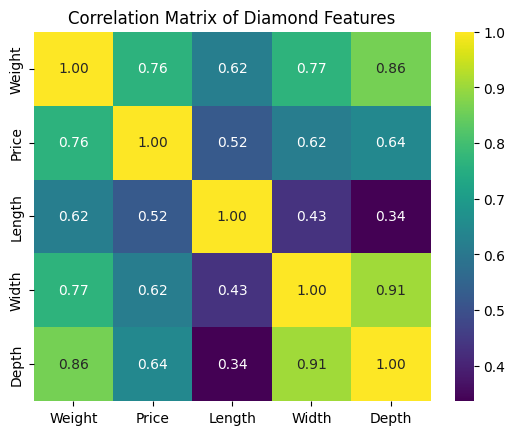

In [45]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation Matrix of Diamond Features")
plt.show()

**Insight 💡**

Using Pearson correlation coefficient we found out that all numeric data positive correlate to each other

## Conclusion 🎉

In this project, we found that all categorical data are ordinal except Shape.

This are the list of ordinal data (best to worst)

- `Polish`: ['EX', 'VG', 'GD', 'FR']
- `Symmetry`: ['EX', 'VG', 'GD', 'FR']
- `Fluorescence`: ['VSL', 'VS', 'ST', 'SL', 'F', 'M', 'N']
- `Cut`: ['EX', 'VG', 'GD', 'FR']
- `Colour`: ['D', 'E', 'F', 'FANCY', ..., 'U-V', 'W', 'W-X', 'Y-Z']
- `Clarity`: ['IF', 'VVS1', 'VVS2', 'VS1','VS2','SI1','SI2','I1','I2', 'I3']

All categorical date are correlate to each other except Cut and Fluorescence.

And all numeric data positive correlate to each other